Configurações Iniciais

In [2]:
#Importar bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, VotingRegressor

np.random.seed(42)

#Importar os dados
data = pd.read_csv('../data/dataarea2.csv', header=0)


In [3]:
#Descartar observações com valores que aparecem menos de 5 vezes
data = data.groupby("guarnição").filter(lambda x: len(x) >= 5)
data = data.groupby("prato_principal_1").filter(lambda x: len(x) >= 5)
data = data.groupby("prato_principal_2").filter(lambda x: len(x) >= 5)
data = data.groupby("sobremesa_1").filter(lambda x: len(x) >= 5)


In [4]:
data_raw_base = data.copy()

# Colunas do dataset ANTES do one-hot — usadas para validar nova_obs mais adiante
colunas_base = data_raw_base.drop(columns=['total']).columns

#Aplicando One Hot Encoding nas variáveis categóricas
data = pd.get_dummies(data, columns=['Mês','Dia_semana','Dia_mês','prato_principal_1',
                                     'prato_principal_2', 'guarnição', 'sobremesa_1'])

# X e y definidos UMA VEZ como DataFrame/Series — não serão reescritos ao longo do notebook
atributos = data.drop(columns=['total']).columns
X = data[atributos]   # DataFrame (preserva feature names)
y = data['total']     # Series

n = len(data)         # número de observações
p = len(atributos)    # número de atributos
print(n, 'observações,', p, 'atributos')


603 observações, 182 atributos


Previsão Intervalar (Conformal Prediction)

In [5]:
def treinar_ensemble_conformal(X, y, alpha=0.05, test_size=0.3, random_state=42):
    """
    Treina o ensemble de conformal prediction e calcula as margens do intervalo.
    """
    nivel_confianca = 1 - alpha

    X_train, X_calib, y_train, y_calib = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    print(f"Treino: {len(X_train)} observações | Calibração: {len(X_calib)} observações")

    # 1. Ensemble de calibração
    ensemble_conformal = VotingRegressor(
        estimators=[('gb', GradientBoostingRegressor(n_estimators=200, random_state=random_state)),
                    ('rf', RandomForestRegressor(n_estimators=200, random_state=random_state))],
        weights=[3, 1]
    )
    ensemble_conformal.fit(X_train, y_train)

    y_calib_pred = ensemble_conformal.predict(X_calib)
    residuos_calib = np.abs(y_calib - y_calib_pred)

    # Dias de transição: primeiros ou últimos 10 dias de semestre
    mascara_transicao  = (X_calib['dias_desde_ultimas_ferias'] <= 10) | (X_calib['dias_ate_ferias'] <= 10)
    residuos_transicao = residuos_calib[mascara_transicao]
    residuos_normais    = residuos_calib[~mascara_transicao]

    margem_transicao = np.quantile(residuos_transicao, nivel_confianca, method='higher')
    margem_normal    = np.quantile(residuos_normais,   nivel_confianca, method='higher')
    margem_total     = np.quantile(residuos_calib,      nivel_confianca, method='higher')

    # 2. Ensemble final, treinado em 100% dos dados
    ensemble = VotingRegressor(
        estimators=[('gb', GradientBoostingRegressor(n_estimators=200, random_state=random_state)),
                    ('rf', RandomForestRegressor(n_estimators=200, random_state=random_state))],
        weights=[3, 1]
    )
    ensemble.fit(X, y)

    print(f"\nCONFORMAL PREDICTION - VALIDAÇÃO:")
    print(f"Margem para Dias de Transição (Início/Fim): ±{margem_transicao:.1f} pessoas ({len(residuos_transicao)} dias analisados)")
    print(f"Margem para Dias Normais: ±{margem_normal:.1f} pessoas ({len(residuos_normais)} dias analisados)")
    print(f"Margem GERAL (sem distinção): ±{margem_total:.1f} pessoas ({len(residuos_calib)} dias analisados)")
    print(f"Mediana GERAL dos resíduos: {np.median(residuos_calib):.1f} pessoas")
    print(f"Média GERAL dos resíduos: {np.mean(residuos_calib):.1f} pessoas")

    return {
        'ensemble': ensemble,
        'ensemble_conformal': ensemble_conformal,
        'X_calib': X_calib,
        'y_calib': y_calib,
        'y_calib_pred': y_calib_pred,
        'margem_transicao': margem_transicao,
        'margem_normal': margem_normal,
        'margem_total': margem_total,
        'nivel_confianca': nivel_confianca,
        'alpha': alpha,
    }


In [6]:
# Treina o ensemble e calcula as margens de conformal prediction (95% de confiança por padrão)
resultado_treino = treinar_ensemble_conformal(X, y, alpha=0.05)


Treino: 422 observações | Calibração: 181 observações

CONFORMAL PREDICTION - VALIDAÇÃO:
Margem para Dias de Transição (Início/Fim): ±131.7 pessoas (56 dias analisados)
Margem para Dias Normais: ±150.8 pessoas (125 dias analisados)
Margem GERAL (sem distinção): ±145.4 pessoas (181 dias analisados)
Mediana GERAL dos resíduos: 39.6 pessoas
Média GERAL dos resíduos: 51.5 pessoas


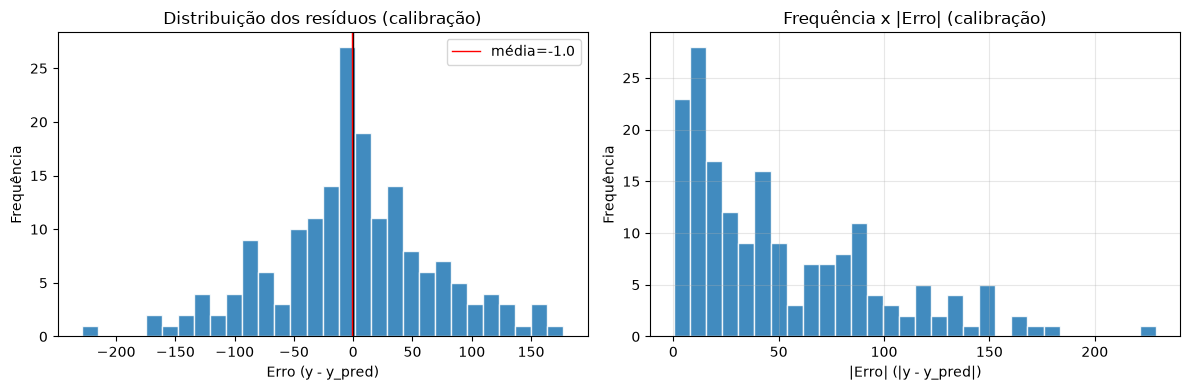

In [7]:
# --- PLOT DO GRÁFICO DOS RESÍDUOS (CALIBRAÇÃO) ---

y_calib      = resultado_treino['y_calib']
y_calib_pred = resultado_treino['y_calib_pred']

# Resíduo com sinal (útil para ver viés): y - y_pred
residuos_assinados_calib = (y_calib.to_numpy() - np.asarray(y_calib_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma dos resíduos (com sinal)
media_res = float(np.mean(residuos_assinados_calib))
axes[0].hist(residuos_assinados_calib, bins=30, alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].axvline(media_res, color='red', linewidth=1, label=f'média={media_res:.1f}')
axes[0].set_title('Distribuição dos resíduos (calibração)')
axes[0].set_xlabel('Erro (y - y_pred)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Frequência x |erro|
abs_erros = np.abs(residuos_assinados_calib)
counts, edges = np.histogram(abs_erros, bins=30)
centers = (edges[:-1] + edges[1:]) / 2
widths = np.diff(edges)
axes[1].bar(centers, counts, width=widths, alpha=0.85, edgecolor='white', align='center')
axes[1].set_title('Frequência x |Erro| (calibração)')
axes[1].set_xlabel('|Erro| (|y - y_pred|)')
axes[1].set_ylabel('Frequência')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
def validar_nova_obs(nova_obs_dict, colunas_base):
    """
    Confere se as chaves de nova_obs batem com as colunas reais do dataset
    (antes do one-hot encoding).
    """
    colunas_base_set = set(colunas_base)
    chaves = set(nova_obs_dict.keys())

    invalidas = sorted(chaves - colunas_base_set)
    faltando  = sorted(colunas_base_set - chaves)

    if invalidas:
        raise ValueError(
            "As seguintes colunas em nova_obs não existem no dataset (confira nomes/typos): "
            f"{invalidas}\n\nColunas válidas disponíveis: {sorted(colunas_base_set)}"
        )

    if faltando:
        print(f"Atenção: colunas do dataset não informadas em nova_obs (serão preenchidas com 0 no one-hot): {faltando}")

    return True


In [9]:
def prever_intervalo(nova_obs_dict, resultado_treino, colunas_base, atributos, y):
    """
    Valida, codifica e prevê o intervalo de confiança para uma observação nova.
    """

    validar_nova_obs(nova_obs_dict, colunas_base)

    nova_obs = pd.DataFrame(nova_obs_dict)
    nova_obs_processed = pd.get_dummies(nova_obs).reindex(columns=atributos, fill_value=0)

    ensemble         = resultado_treino['ensemble']
    margem_transicao = resultado_treino['margem_transicao']
    margem_normal    = resultado_treino['margem_normal']
    nivel_confianca  = resultado_treino['nivel_confianca']

    # Mesmo critério usado em treinar_ensemble_conformal para separar os resíduos
    dias_desde_ultimas_ferias = nova_obs_dict['dias_desde_ultimas_ferias'][0]
    dias_ate_ferias           = nova_obs_dict['dias_ate_ferias'][0]
    is_transicao = (dias_desde_ultimas_ferias <= 10) or (dias_ate_ferias <= 10)

    if is_transicao:
        margem_usada = margem_transicao
        tipo_dia = "Transição (início/fim de férias)"
    else:
        margem_usada = margem_normal
        tipo_dia = "Normal"

    pred_central = ensemble.predict(nova_obs_processed)[0]
    limite_inf   = max(y.min(), pred_central - margem_usada)
    limite_sup   = pred_central + margem_usada

    print(f"\nPrevisão Central: {int(round(pred_central))} pessoas esperadas")
    print(f"\nTipo de dia (para escolha da margem): {tipo_dia}")
    print(f"\nIntervalo de Confiança ({nivel_confianca*100:.1f}%):")
    print(f"  Limite Inferior: {int(round(limite_inf))} pessoas")
    print(f"  Previsão: {int(round(pred_central))} pessoas")
    print(f"  Limite Superior: {int(round(limite_sup))} pessoas")
    print(f"\n  Amplitude: {int(round(limite_sup - limite_inf))} pessoas")
    print(f"  Margem usada: ±{int(round(margem_usada))} pessoas")
    print(f"\nGarantias Estatísticas:")
    print(f"  Nível de Confiança: {nivel_confianca*100:.1f}%")
    print(f"  Calibração: {len(resultado_treino['y_calib'])} observações")

    return {
        'pred_central': pred_central,
        'limite_inf': limite_inf,
        'limite_sup': limite_sup,
        'tipo_dia': tipo_dia,
        'margem_usada': margem_usada,
    }


In [10]:
#--- PREDIÇÃO FOCADA COM CONFORMAL PREDICTION ---

nova_obs_dict = {
    'Ano': [2025],                    # ano da previsão
    'Precipitacao_mm': [0],
    'Temp_max_C': [25],
    'Temp_min_C': [20],
    'Umid_rel_ar': [50],
    'Vento_velocidade_ms': [3],
    'Vento_rajada_maxima_ms': [3],
    'Dia_mês': [25],
    'Dia_semana': ['ter'],
    'Mês': [3],
    'prato_principal_1': ['lasanha à bolonhesa'],
    'prato_principal_2': ['curry de legumes'],
    'guarnição': ['legumes sautê'],
    'sobremesa_1': ['goiabada'],
    'letivo': [1],
    'vespera_nao_letivo': [0],
    'pos_nao_letivo': [0],
    'dias_desde_ultimas_ferias': [90],
    'dias_ate_ferias': [90],
    'feriado': [0],
    'ferias': [0],
    'vespera_feriado': [0],
    'pos_feriado': [0],
    'dias_desde_inicio_ferias': [0],
    'dias_ate_feriado': [90],
}

resultado_previsao = prever_intervalo(nova_obs_dict, resultado_treino, colunas_base, atributos, y)



Previsão Central: 611 pessoas esperadas

Tipo de dia (para escolha da margem): Normal

Intervalo de Confiança (95.0%):
  Limite Inferior: 460 pessoas
  Previsão: 611 pessoas
  Limite Superior: 762 pessoas

  Amplitude: 302 pessoas
  Margem usada: ±151 pessoas

Garantias Estatísticas:
  Nível de Confiança: 95.0%
  Calibração: 181 observações


In [11]:
# Lista as observações (dias) com maior e menor |resíduo|
# IMPORTANTE: usa a base pré-one-hot (data_raw_base) para garantir consistência de índice com X_calib.

X_calib      = resultado_treino['X_calib']
y_calib_pred = resultado_treino['y_calib_pred']

data_raw = data_raw_base.copy()

# Seleciona exatamente as linhas usadas na calibração (mesmo índice)
out = data_raw.loc[X_calib.index].copy()

# Alinha a predição por índice (robusto a qualquer reordenação)
pred_series = pd.Series(y_calib_pred, index=X_calib.index, name='Predição')
out['Predição'] = pred_series.loc[out.index].to_numpy()

# Resíduo (com sinal): Total - Predição
out['Resíduo'] = out['total'].to_numpy() - out['Predição'].to_numpy()
out['Resíduo_abs'] = np.abs(out['Resíduo'])

piores20   = out.sort_values('Resíduo_abs', ascending=False).head(20)
melhores20 = out.sort_values('Resíduo_abs', ascending=True).head(20)

cols_chave = [
    'Ano','Mês','Dia_mês','Dia_semana',
    'total','Predição','Resíduo','Resíduo_abs',
    'letivo', 'feriado', 'ferias', 'vespera_nao_letivo','pos_nao_letivo',
    'dias_desde_ultimas_ferias', 'dias_desde_inicio_ferias', 'dias_ate_feriado','dias_ate_ferias',
    'Precipitacao_mm','Temp_max_C','Temp_min_C','Umid_rel_ar',
    'Vento_velocidade_ms','Vento_rajada_maxima_ms',
    'prato_principal_1','prato_principal_2','guarnição','sobremesa_1',
]
cols_chave = [c for c in cols_chave if c in out.columns]

print("\nTop 20 dias com maior resíduo absoluto (|Total - ŷ|) na calibração:\n")
display(piores20[cols_chave] if cols_chave else piores20)

print("\nTop 20 dias com menor resíduo absoluto (|Total - ŷ|) na calibração:\n")
display(melhores20[cols_chave] if cols_chave else melhores20)



Top 20 dias com maior resíduo absoluto (|Total - ŷ|) na calibração:



,Ano,Mês,Dia_mês,Dia_semana,total,Predição,Resíduo,Resíduo_abs,letivo,feriado,...,Precipitacao_mm,Temp_max_C,Temp_min_C,Umid_rel_ar,Vento_velocidade_ms,Vento_rajada_maxima_ms,prato_principal_1,prato_principal_2,guarnição,sobremesa_1
644,2025,10,14,ter,418.0,647.021919,-229.021919,229.021919,1,0,...,0.000000,25.000000,23.000000,68.666667,1.266667,4.300000,Lasanha bolonhesa,Lasanha de PVT,Repolho,Doce de leite
424,2024,9,24,ter,812.0,634.706734,177.293266,177.293266,1,0,...,0.000000,34.050000,31.300000,24.500000,1.950000,8.650000,Hamburguer,Hamburguer de lentilha,Macarrão,Picolé
350,2024,6,19,qua,336.0,508.403845,-172.403845,172.403845,1,0,...,0.000000,25.666667,23.900000,32.666667,2.866667,8.033333,Filé de peixe,Grãos com queijo,Couve-flor,Cocada
412,2024,9,9,seg,409.0,572.516212,-163.516212,163.516212,1,0,...,0.000000,31.933333,29.600000,22.666667,1.400000,6.200000,Frango empanado,Suflê de legumes,Creme de milho,Barra de cereais
275,2024,3,18,seg,749.0,587.897743,161.102257,161.102257,1,0,...,0.000000,30.600000,28.600000,55.666667,0.900000,3.966667,Linguiça,Grão de bico,Virado,Iogurte
28,2023,3,31,sex,519.0,366.698808,152.301192,152.301192,1,0,...,0.000000,29.166667,27.433333,57.000000,1.933333,5.700000,Bife,Lasanha de queijo,Couve-flor,Gelatina
552,2025,6,24,ter,587.0,436.172805,150.827195,150.827195,1,0,...,0.000000,14.700000,13.000000,51.666667,1.300000,5.300000,Carne moída,Hamburguer de PVT,Ervilha parmentier,Bombom
666,2025,11,24,seg,320.0,467.909935,-147.909935,147.909935,1,0,...,0.000000,21.800000,20.000000,80.000000,0.766667,6.200000,Bife,Batata especial,Vagem,Goiabada
99,2023,7,4,ter,369.0,516.575663,-147.575663,147.575663,1,0,...,0.000000,20.366667,18.566667,50.666667,2.833333,6.700000,Isca de frango,Grão de bico,Batata palha,Canjica
400,2024,8,23,sex,260.0,405.448160,-145.448160,145.448160,1,0,...,0.000000,31.466667,29.166667,19.000000,4.333333,10.866667,Carne em cubos,Quibe de brócolis,Nhoque,Pudim de pão



Top 20 dias com menor resíduo absoluto (|Total - ŷ|) na calibração:



,Ano,Mês,Dia_mês,Dia_semana,total,Predição,Resíduo,Resíduo_abs,letivo,feriado,...,Precipitacao_mm,Temp_max_C,Temp_min_C,Umid_rel_ar,Vento_velocidade_ms,Vento_rajada_maxima_ms,prato_principal_1,prato_principal_2,guarnição,sobremesa_1
106,2023,7,12,qua,372.0,372.417030,-0.417030,0.417030,1,0,...,0.000000,26.166667,24.533333,37.333333,2.466667,6.733333,Estrogonofe de carne,Estrogonofe de grão de bico,Batata,Bolinho
593,2025,8,12,ter,657.0,656.391439,0.608561,0.608561,1,0,...,0.000000,20.000000,18.266667,38.666667,0.933333,6.766667,Carne em cubos,Omelete,Legumes,Bombom
679,2025,12,18,qui,101.0,100.376844,0.623156,0.623156,0,0,...,0.133333,22.433333,20.833333,79.000000,2.433333,6.233333,Estrogonofe de carne,Bife de grão de bico,Batata palha,Bombom
655,2025,11,5,qua,464.0,464.751388,-0.751388,0.751388,1,0,...,0.000000,28.066667,27.000000,64.666667,1.866667,6.066667,Frango empanado,Omelete,Creme de milho,Bolinho
196,2023,11,9,qui,502.0,501.200025,0.799975,0.799975,1,0,...,0.000000,31.500000,29.666667,35.333333,3.000000,8.333333,Carne em cubos,Almôndega de aveia,Macarrão,Manjar
94,2023,6,28,qua,569.0,567.761740,1.238260,1.238260,1,0,...,0.000000,24.733333,23.100000,44.333333,2.400000,7.033333,Filé de frango,Lasanha de queijo,Cenoura,Gelatina
612,2025,9,5,sex,93.0,95.168685,-2.168685,2.168685,0,1,...,0.000000,29.000000,27.033333,25.000000,2.166667,7.133333,Peixe frito,Lasanha de abobrinha,Purês,Doce de abóbora
591,2025,8,9,sáb,0.0,2.405912,-2.405912,2.405912,1,0,...,0.000000,18.866667,16.766667,50.666667,2.266667,6.900000,Bife,Tomate recheado,Polenta,Arroz doce
535,2025,5,31,sáb,0.0,-2.606102,2.606102,2.606102,1,0,...,0.000000,23.533333,21.700000,48.333333,1.700000,5.433333,Isca de carne,PVT,Cenoura,Bolinho
607,2025,8,30,sáb,0.0,3.220600,-3.220600,3.220600,1,0,...,0.000000,24.866667,22.833333,41.000000,2.533333,6.800000,Bife,Bife de feijão,Cuscuz,Mosaico
